In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install patchify

In [3]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import cv2
from PIL import Image
from patchify import patchify
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import random

In [4]:
minmaxscalar = MinMaxScaler()

In [5]:
ls -lah

total 20K
drwxr-xr-x 1 root root 4.0K Dec  5 13:11 ./
drwxr-xr-x 1 root root 4.0K Dec  5 12:33 ../
drwxr-xr-x 4 root root 4.0K Dec  3 19:31 .config/
drwx------ 7 root root 4.0K Dec  5 13:11 drive/
drwxr-xr-x 1 root root 4.0K Dec  3 19:31 sample_data/


In [6]:
dataset_root_folder = '/content/drive/MyDrive/major/'

In [7]:
dataset_name = 'Folder'

In [8]:
for path, subdirs, files in os.walk(os.path.join(dataset_root_folder, dataset_name)):
  dir_name = path.split(os.path.sep)[-1]
  #print(dir_name)
  if dir_name == 'images': #masks
    images = os.listdir(path)
    #print(path)
    #print(images)
    for i, image_name in enumerate(images):
      if(image_name.endswith('.jpg')): #.png
        #print(image_name)

        a = True

In [9]:
image_patch_size = 256

In [10]:
image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/images/image_01.jpg',1)

In [11]:
image.shape

(6715, 4297, 3)

In [12]:
image_patches = patchify(image, (image_patch_size, image_patch_size, 3), step = image_patch_size)

In [13]:
print(image_patches.shape)

(26, 16, 1, 256, 256, 3)


In [14]:
image_x = image_patches[0,0,:,:]

#MinMaxScalar
image_y = minmaxscalar.fit_transform(image_x.reshape(-1, image_x.shape[-1])).reshape(image_x.shape)

In [15]:
image_y[0].shape

(256, 256, 3)

In [16]:


print(type(image))

<class 'numpy.ndarray'>


In [17]:
type(Image.fromarray(image))

PIL.Image.Image

In [18]:
image.shape

(6715, 4297, 3)

In [19]:
(image.shape[0]//image_patch_size)*image_patch_size
(image.shape[1]//image_patch_size)*image_patch_size

4096

In [20]:
image_dataset = []
mask_dataset = []

for image_type in ['images' , 'masks']:
  if image_type == 'images':
    image_extension = 'jpg'
  elif image_type == 'masks':
     image_extension = 'png'
  for image_id in range(1,9):
      image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/image_0{image_id}.{image_extension}',1)
      if image is not None:
        if image_type == 'masks':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #print(image.shape)
        size_x = (image.shape[1]//image_patch_size)*image_patch_size
        size_y = (image.shape[0]//image_patch_size)*image_patch_size
        #print("{} --- {} - {}".format(image.shape, size_x, size_y))
        image = Image.fromarray(image)
        image = image.crop((0,0, size_x, size_y))
        #print("({},  {})".format(image.size[0],image.size[1]))
        image = np.array(image)
        patched_images = patchify(image, (image_patch_size, image_patch_size, 3), step=image_patch_size)
        #print(len(patched_images))
        for i in range(patched_images.shape[0]):
          for j in range(patched_images.shape[1]):
            if image_type == 'images':
              individual_patched_image = patched_images[i,j,:,:]
              #print(individual_patched_image.shape)
              individual_patched_image = minmaxscalar.fit_transform(individual_patched_image.reshape(-1, individual_patched_image.shape[-1])).reshape(individual_patched_image.shape)
              individual_patched_image = individual_patched_image[0]
              #print(individual_patched_image.shape)
              image_dataset.append(individual_patched_image)
            elif image_type == 'masks':
              individual_patched_mask = patched_images[i,j,:,:]
              individual_patched_mask = individual_patched_mask[0]
              mask_dataset.append(individual_patched_mask)

In [21]:
print(len(image_dataset))
print(len(mask_dataset))

3182
3182


In [22]:
image_dataset = np.array(image_dataset)
mask_dataset = np.array(mask_dataset)

In [23]:
print(len(image_dataset))
print(len(mask_dataset))

3182
3182


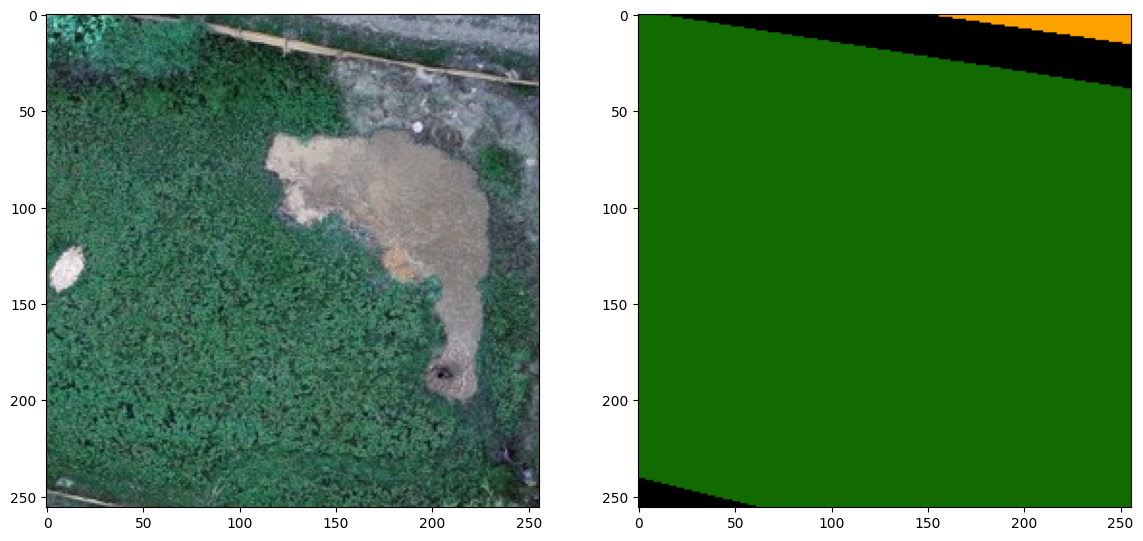

In [24]:
random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
plt.imshow(mask_dataset[random_image_id])


In [25]:
class_building = '#FF0D00'
class_building = class_building.lstrip('#')
class_building = np.array(tuple(int(class_building[i:i+2], 16) for i in (0, 2, 4)))
print(class_building)

class_land = '#FFA200'
class_land = class_land.lstrip('#')
class_land = np.array(tuple(int(class_land[i:i+2], 16) for i in (0, 2, 4)))
print(class_land)

class_road = '#A020F0'
class_road = class_road.lstrip('#')
class_road = np.array(tuple(int(class_road[i:i+2], 16) for i in (0, 2, 4)))
print(class_road)

class_vegetation = '#126B00'
class_vegetation = class_vegetation.lstrip('#')
class_vegetation = np.array(tuple(int(class_vegetation[i:i+2], 16) for i in (0, 2, 4)))
print(class_vegetation)

class_water = '#006EFF'
class_water = class_water.lstrip('#')
class_water = np.array(tuple(int(class_water[i:i+2], 16) for i in (0, 2, 4)))
print(class_water)


In [26]:
print(mask_dataset.shape)

In [27]:
individual_patched_mask.shape

(256, 256, 3)

In [28]:
label = individual_patched_mask

In [29]:
def rgb_to_label(label):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_land, axis=-1)] = 0
  label_segment[np.all(label == class_building, axis=-1)] = 1
  label_segment[np.all(label == class_road, axis=-1)] = 2
  label_segment[np.all(label == class_vegetation, axis=-1)] = 3
  label_segment[np.all(label == class_water, axis=-1)] = 4
  #print(label_segment)
  label_segment = label_segment[:,:,0]
  #print(label_segment)
  return label_segment

[255  13   0]
[255 162   0]
[160  32 240]
[ 18 107   0]
[  0 110 255]
(3182, 256, 256, 3)


In [30]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

In [31]:
len(labels)

3182

In [32]:
labels = np.array(labels)

array([[0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
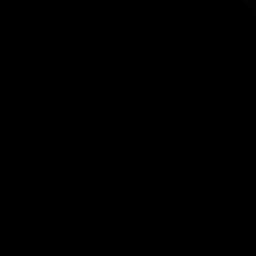

In [33]:
labels[1]

In [34]:
labels = np.expand_dims(labels, axis=3)

In [35]:
labels[0]

array([[[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       ...,

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]],

       [[0],
        [0],
        [0],
        ...,
        [0],
        [0],
        [0]]], dtype=uint8)

In [36]:
np.unique(labels)

array([0, 1, 2, 3, 4], dtype=uint8)

In [37]:
print("Total unique values based on masks: ",format(np.unique(labels)))

Total unique values based on masks:  [0 1 2 3 4]


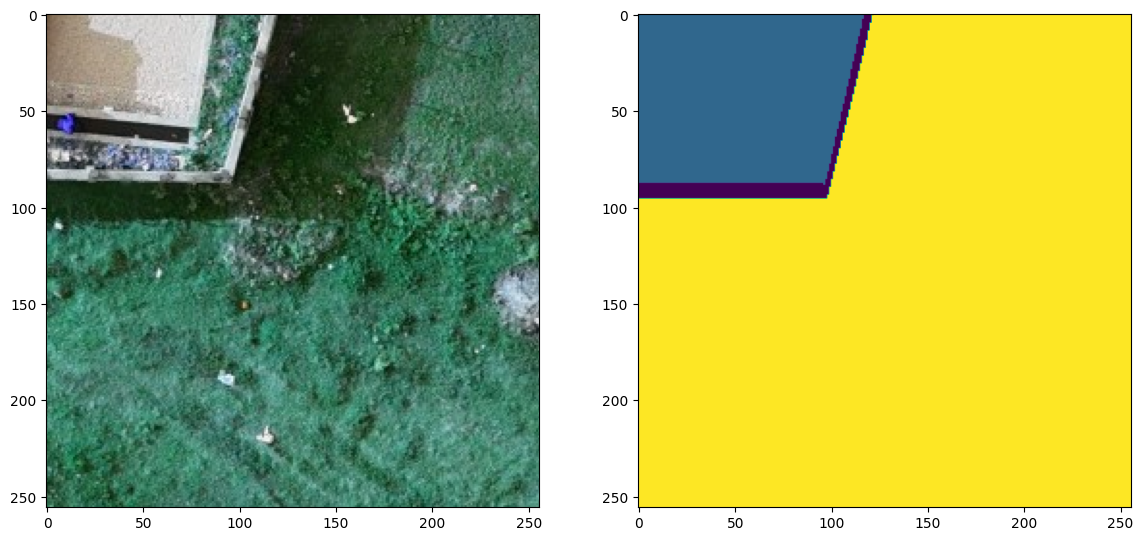

In [38]:
random_image_id = random.randint(0, len(image_dataset)-1)

plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.imshow(image_dataset[random_image_id])
plt.subplot(1,2,2)
#plt.imshow(mask_dataset[random_image_id])
plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
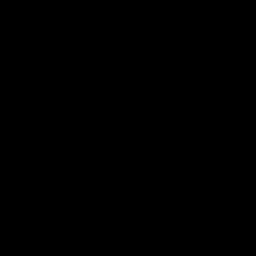

In [39]:
labels[0][:,:,0]

In [40]:
total_classes = len(np.unique(labels))

In [41]:
total_classes

5

In [42]:
from tensorflow.keras.utils import to_categorical

In [ ]:
labels_categorical_dataset = to_categorical(labels, num_classes = total_classes)

In [ ]:
labels_categorical_dataset.shape

In [ ]:
master_training_dataset = image_dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(master_training_dataset, labels_categorical_dataset, test_size=0.15, random_state = 100)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

In [ ]:
image_height = x_train.shape[1]
image_width = x_train.shape[2]
image_channels = x_train.shape[3]
total_classes = y_train.shape[3]

In [ ]:
print(image_height)
print(image_width)
print(image_channels)
print(total_classes)

In [ ]:
 pip install --upgrade tensorflow keras segmentation-models

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda


In [ ]:
from keras import backend as K

In [ ]:
import tensorflow.keras.backend as K
import segmentation_models as sm
import tensorflow as tf

In [ ]:
def jaccard_coef(y_true, y_pred):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)
    intersection = K.sum(y_true_flatten * y_pred_flatten)
    final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 0.1)
    return final_coef_value

In [ ]:
from ctypes import c_int8
def multi_unet_model(n_classes = 5, image_height = 256, image_width = 256, image_channels = 1):

  inputs = Input((image_height, image_width, image_channels))

  source_input = inputs

  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c1)
  p1 = MaxPooling2D((2,2))(c1)

  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p1)
  c2= Dropout(0.2)(c2)
  c2 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c2)
  p2 = MaxPooling2D((2,2))(c2)

  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p2)
  c3= Dropout(0.2)(c3)
  c3 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c3)
  p3 = MaxPooling2D((2,2))(c3)

  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p3)
  c4= Dropout(0.2)(c4)
  c4 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c4)
  p4 = MaxPooling2D((2,2))(c4)

  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(p4)
  c5= Dropout(0.2)(c5)
  c5 = Conv2D(256, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c5)

  u6 = Conv2DTranspose(128, (2,2), strides = (2,2), padding='same')(c5)
  u6 = concatenate([u6, c4])

  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(128, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c6)

  u7 = Conv2DTranspose(64, (2,2), strides = (2,2), padding='same')(c6)
  u7 = concatenate([u7, c3])

  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(64, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c7)

  u8 = Conv2DTranspose(32, (2,2), strides = (2,2), padding='same')(c7)
  u8 = concatenate([u8, c2])

  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(32, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c8)

  u9 = Conv2DTranspose(16, (2,2), strides = (2,2), padding='same')(c8)
  u9 = concatenate([u9, c1], axis=3)

  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(16, (3,3), activation = 'relu', kernel_initializer='he_normal',padding = 'same')(c9)

  outputs = Conv2D(n_classes, (1,1), activation = 'softmax')(c9)

  model = Model(inputs = [inputs], outputs = [outputs])

  return model




In [ ]:
def get_deep_learning_model():
  return multi_unet_model(n_classes = total_classes, image_height = image_height, image_width = image_width, image_channels = image_channels)

In [ ]:
model = get_deep_learning_model()

In [ ]:
weights = tf.constant([0.166, 0.166, 0.166, 0.166, 0.166])  # 5 classes

In [ ]:
import segmentation_models as sm

In [ ]:
dice_loss = sm.losses.DiceLoss(class_weights=weights)
focal_loss = sm.losses.CategoricalFocalLoss()
total_loss = dice_loss + (1 * focal_loss)


In [ ]:
import tensorflow as tf

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
model.compile(optimizer = 'adam', loss = total_loss, metrics = ['accuracy', jaccard_coef])

In [ ]:
model.summary()

In [ ]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")


In [ ]:
model_history = model.fit(
    x_train, y_train,
    batch_size=16,
    verbose=1,
    epochs=100,
    validation_data=(x_test, y_test),
    shuffle=False
)